In [3]:
%load_ext autoreload
%autoreload 2

import torch 
import os
#set project root
# Récupérer le répertoire du notebook actuel
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
# Remonter de deux niveaux dans l'arborescence pour atteindre la racine du projet
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
# Changer le répertoire de travail
os.chdir(project_root)
print(os.getcwd())
import numpy as np
import scipy as sp
from src import utils
from torch import nn
from torch import optim
import matplotlib.pyplot as plt
from src.net import TMA_net
from src.training.training import Trainer
from src.utils.misc import TrainerConfig
import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from src.utils.misc import snv
from scipy.signal import savgol_filter
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project


In [4]:
 

mango_original = pd.read_csv(r"Deep-Chemometrics\data\dataset\Mango\NAnderson2020MendeleyMangoNIRDataV3.csv")
file = mango_original.copy()




In [5]:

 
# Colonnes stables pour définir une joue de mangue (échantillon)
replicate_cols = ['Set', 'Season', 'Region', 'Date', 'Type', 'Cultivar', 'Pop', 'DM']
 
# Regroupement pour définir les samples uniques
file['sample'] = file.groupby(replicate_cols).ngroup() + 1
file['sample'] = file['sample'].apply(lambda x: f'sample {x}')
 
# Placer 'sample' en 10e colonne
cols = list(file.columns)
cols.remove('sample')
cols.insert(9, 'sample')
file = file[cols]
 
# Chaque joue de mangue est mesurée 2 ou 6 fois, aucun échantillon ne devrait être seul.
# Extraire samples seuls
sample_counts = file['sample'].value_counts()
single_samples = sample_counts[sample_counts == 1].index.tolist()
df_single = file[file['sample'].isin(single_samples)][['sample', 'DM']]
 
# Trier par DM pour plus d'efficacité
df_single = df_single.sort_values('DM').reset_index(drop=True)
 
# Chercher paires avec DM proche
close_pairs = []
 
for i in range(len(df_single)):
    for j in range(i+1, len(df_single)):
        diff = abs(df_single.loc[i, 'DM'] - df_single.loc[j, 'DM'])
        if diff <= 0.0001:
            close_pairs.append((df_single.loc[i, 'sample'], df_single.loc[j, 'sample'], diff))
        else:
            # Comme le dataframe est trié, on peut break pour gagner du temps
            break
 
# Afficher les paires proches
for s1, s2, d in close_pairs:
    print(f"{s1} et {s2} ont un DM proche (diff = {d:.4f})")
 
# grouper les mangues seules
file['sample'] = file['sample'].replace({'sample 574': 'sample 575', 'sample 853': 'sample 854'})
print(file['sample'].nunique()) # on obtient 4675 échantillons (joues de mangues) dont ils parlent dans le papier
 
# Liste des spectres groupés par joue
duplicate_list = file.groupby(['sample']).apply(lambda x: list(x.index)).dropna().tolist()
 
# Split into training, validation and test sets
cal_val_indices, test_indices = train_test_split(duplicate_list, test_size=0.2, random_state=42)
cal_indices, val_indices = train_test_split(cal_val_indices, test_size=0.2, random_state=42)
 
# Flatten the lists
cal_indices = [item for sublist in cal_indices for item in sublist]
val_indices = [item for sublist in val_indices for item in sublist]
test_indices = [item for sublist in test_indices for item in sublist]
 
# save the sets
dataset_random_split = {
    "Xcal": file.iloc[cal_indices].drop(columns=["Set", "Season", "Region", "Date", "Type", "Cultivar", "Pop", "Temp", "DM", "sample"]).to_numpy(),
    "Xval": file.iloc[val_indices].drop(columns=["Set", "Season", "Region", "Date", "Type", "Cultivar", "Pop", "Temp", "DM", "sample"]).to_numpy(),
    "Xtest": file.iloc[test_indices].drop(columns=["Set", "Season", "Region", "Date", "Type", "Cultivar", "Pop", "Temp", "DM", "sample"]).to_numpy(),
    "Ycal": np.expand_dims(file.iloc[cal_indices]["DM"].to_numpy(), axis=1), # expand dims so the shape is (n,1) instead of (n,)
    "Yval": np.expand_dims(file.iloc[val_indices]["DM"].to_numpy(), axis=1),
    "Ytest": np.expand_dims(file.iloc[test_indices]["DM"].to_numpy(), axis=1),
}
 

sample 574 et sample 575 ont un DM proche (diff = 0.0000)
sample 853 et sample 854 ont un DM proche (diff = 0.0001)
4835


C:\Users\danie\AppData\Local\Temp\ipykernel_4196\995284460.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duplicate_list = file.groupby(['sample']).apply(lambda x: list(x.index)).dropna().tolist()


In [6]:
Ycal = dataset_random_split["Ycal"]
Yval = dataset_random_split["Yval"]
Ytest = dataset_random_split["Ytest"]
Xcal = dataset_random_split["Xcal"][:,50:-50]
Xval = dataset_random_split["Xval"][:,50:-50]
Xtest = dataset_random_split["Xtest"][:,50:-50]
print("X and Y training set")
print(Ycal.shape)
print(Xcal.shape)

print("X and Y val set")
print(Yval.shape)
print(Xval.shape)

print("X and Y testing set")
print(Ytest.shape)
print(Xtest.shape)

X and Y training set
(7718, 1)
(7718, 206)
X and Y val set
(1955, 1)
(1955, 206)
X and Y testing set
(2338, 1)
(2338, 206)


Text(0.5, 0.98, 'Histogram of Y sets')

<Figure size 1200x600 with 0 Axes>

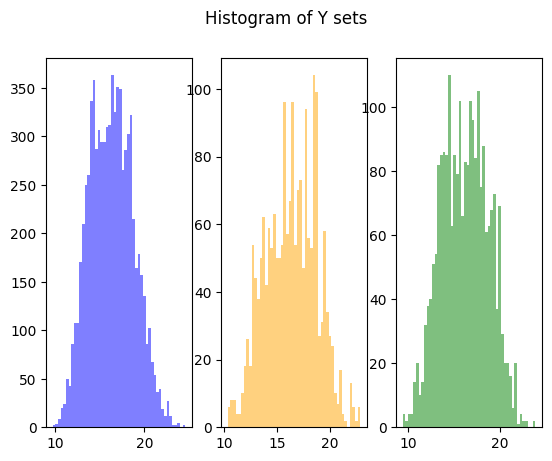

In [7]:
# plot histogram of each Y set
plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(1, 3)
ax[0].hist(Ycal, bins=50, alpha=0.5, label='Ycal', color='blue')
ax[1].hist(Yval, bins=50, alpha=0.5, label='Yval', color='orange')
ax[2].hist(Ytest, bins=50, alpha=0.5, label='Ytest', color='green')
plt.suptitle('Histogram of Y sets')


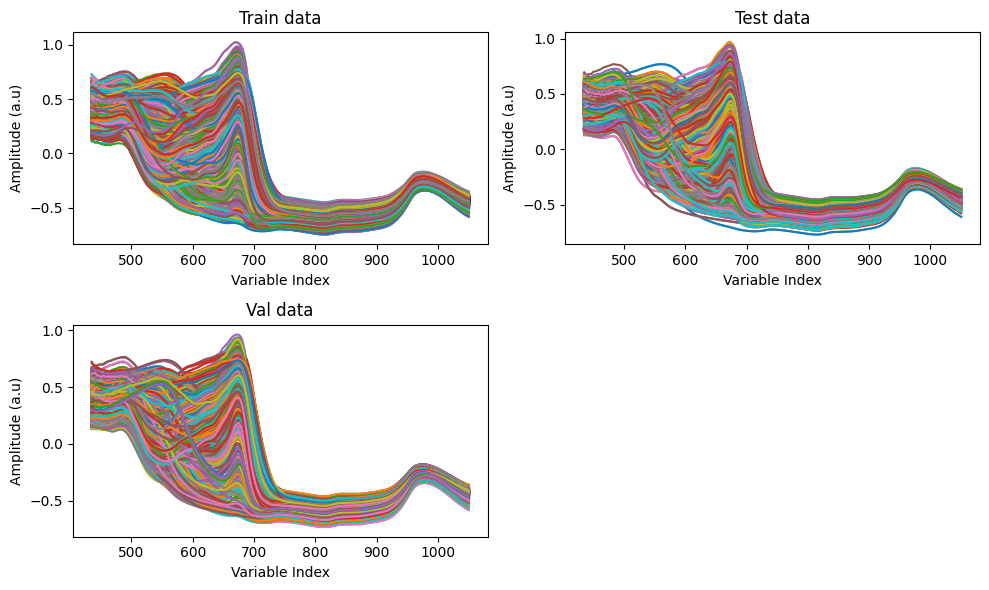

In [8]:
lmb = file.columns[-306:]
lmb = lmb.values.astype(int)[50:-50]
plt.figure(figsize=(10,6))
plt.subplot(221)
plt.title('Train data')
plt.plot(lmb,Xcal.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(222)
plt.title('Test data')
plt.plot(lmb, Xtest.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(223)
plt.title('Val data')
plt.plot(lmb, Xval.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')

plt.tight_layout()
plt.show()

In [9]:
SG_Width = 13
SG_poly = 2

x_cal_snv = snv(Xcal)
x_val_snv = snv(Xval)
x_test_snv = snv(Xtest)

x_cal_SG1 = savgol_filter(Xcal, SG_Width, SG_poly, deriv = 1,axis=0)
x_val_SG1 = savgol_filter(Xval, SG_Width, SG_poly, deriv = 1,axis=0)
x_test_SG1 = savgol_filter(Xtest, SG_Width, SG_poly, deriv = 1,axis=0)


x_cal_SG2 = savgol_filter(Xcal, SG_Width, SG_poly, deriv = 2,axis=0)
x_val_SG2 = savgol_filter(Xval, SG_Width, SG_poly, deriv = 2,axis=0)
x_test_SG2= savgol_filter(Xtest, SG_Width, SG_poly, deriv = 2,axis=0)

x_cal_snv_SG1 = savgol_filter(x_cal_snv, SG_Width, SG_poly, deriv = 1,axis=0)
x_val_snv_SG1 = savgol_filter(x_val_snv, SG_Width, SG_poly, deriv = 1,axis=0)
x_test_snv_SG1 = savgol_filter(x_test_snv, SG_Width, SG_poly, deriv = 1,axis=0)


x_cal_snv_SG2 = savgol_filter(x_cal_snv, SG_Width, SG_poly, deriv = 2,axis=0)
x_val_snv_SG2 = savgol_filter(x_val_snv, SG_Width, SG_poly, deriv = 2,axis=0)
x_test_snv_SG2= savgol_filter(x_test_snv, SG_Width, SG_poly, deriv = 2,axis=0)

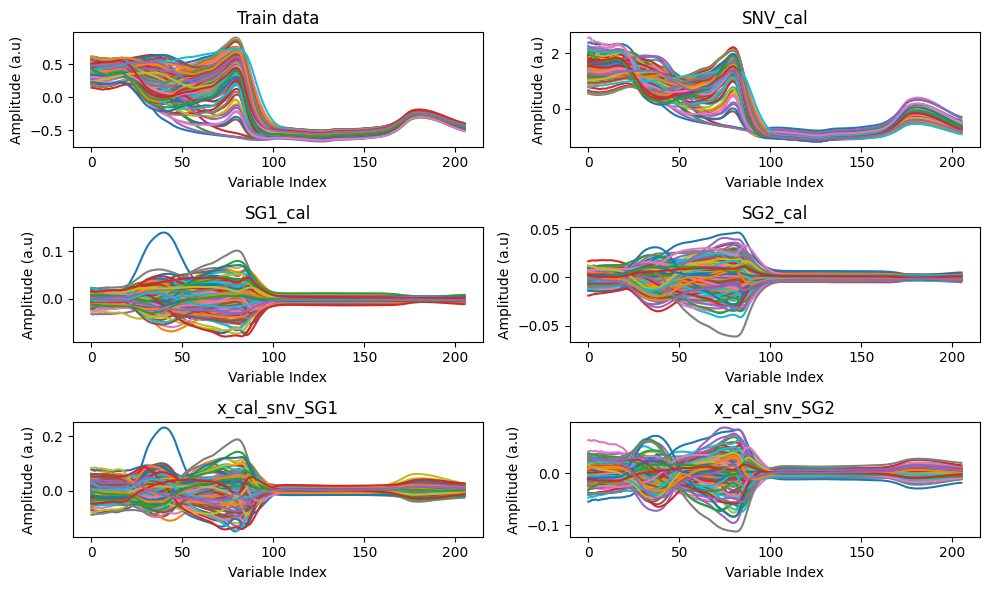

In [10]:
plt.figure(figsize=(10,6))
plt.subplot(321)
plt.title('Train data')
plt.plot(Xcal[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(322)
plt.title('SNV_cal')
plt.plot(x_cal_snv[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(323)
plt.title('SG1_cal')
plt.plot(x_cal_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(324)
plt.title('SG2_cal')
plt.plot(x_cal_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(325)
plt.title('x_cal_snv_SG1')
plt.plot(x_cal_snv_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(326)
plt.title('x_cal_snv_SG2')
plt.plot(x_cal_snv_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.tight_layout()
plt.show()



In [11]:
# Concatenate the preprocessed data
# unsqueeze the data to add a channel dimension
Xcal = np.expand_dims(Xcal, axis=2)
Xval = np.expand_dims(Xval, axis=2)
Xtest = np.expand_dims(Xtest, axis=2)

x_cal_snv = np.expand_dims(x_cal_snv, axis=2)
x_val_snv = np.expand_dims(x_val_snv, axis=2)
x_test_snv = np.expand_dims(x_test_snv, axis=2)

x_cal_SG1 = np.expand_dims(x_cal_SG1, axis=2)
x_val_SG1 = np.expand_dims(x_val_SG1, axis=2)
x_test_SG1 = np.expand_dims(x_test_SG1, axis=2)

x_cal_SG2 = np.expand_dims(x_cal_SG2, axis=2)
x_val_SG2 = np.expand_dims(x_val_SG2, axis=2)
x_test_SG2 = np.expand_dims(x_test_SG2, axis=2)

x_cal_snv_SG1 = np.expand_dims(x_cal_snv_SG1, axis=2)
x_val_snv_SG1 = np.expand_dims(x_val_snv_SG1, axis=2)
x_test_snv_SG1 = np.expand_dims(x_test_snv_SG1, axis=2)

x_cal_snv_SG2 = np.expand_dims(x_cal_snv_SG2, axis=2)
x_val_snv_SG2 = np.expand_dims(x_val_snv_SG2, axis=2)
x_test_snv_SG2 = np.expand_dims(x_test_snv_SG2, axis=2)
# Concatenate the data along the channel dimension
Xcal_concat = np.concatenate((Xcal, x_cal_snv, x_cal_SG1, x_cal_SG2, x_cal_snv_SG1, x_cal_snv_SG2), axis=2)
Xval_concat = np.concatenate((Xval, x_val_snv, x_val_SG1, x_val_SG2, x_val_snv_SG1, x_val_snv_SG2), axis=2)
Xtest_concat = np.concatenate((Xtest, x_test_snv, x_test_SG1, x_test_SG2, x_test_snv_SG1, x_test_snv_SG2), axis=2)
print("Xcal_concat shape:", Xcal_concat.shape)
print("Xval_concat shape:", Xval_concat.shape)
print("Xtest_concat shape:", Xtest_concat.shape) 


Xcal_concat shape: (7718, 206, 6)
Xval_concat shape: (1955, 206, 6)
Xtest_concat shape: (2338, 206, 6)


In [13]:
## Reshape according Torch training requirements
Xcal_concat = Xcal_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
Xval_concat = Xval_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
Xtest_concat = Xtest_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)

## Check for dimensions
print('Data set dimensions ----------------------------')
print('Full Train set dims X Y = {}\t{}'.format(Xcal_concat.shape, Ycal.shape))
print('Test set dims X Y = {}\t{}'.format(Xtest_concat.shape, Ytest.shape))



Data set dimensions ----------------------------
Full Train set dims X Y = (7718, 206, 6)	(7718, 1)
Test set dims X Y = (2338, 206, 6)	(2338, 1)


In [ ]:
# calculate mean and std per column

mean = np.mean(Xcal_concat, axis=0)
std = np.std(Xcal_concat, axis=0)
print("Mean shape:", mean.shape)
print("Std shape:", std.shape)


Mean shape: (206, 6)
Std shape: (206, 6)
Spectral dimensions: 6
TrainerConfig(batch_size=1024, learning_rate=0.01, num_epochs=100, device=cpu, save_model=True,  classification=False, max_loss_plot=20,save_path=C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango)


In [38]:

model_name ="TMA_Mango"

spec_dims = Xcal_concat.shape[2]
print("Spectral dimensions:", spec_dims)

# create trainer config
config = TrainerConfig(model_name = model_name)
config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=3,classification=False,max_loss_plot=20)
print(config)

x_cal_std = (Xcal_concat - mean) / std
x_val_std = (Xval_concat - mean) / std    
Xtest_concat_std = (Xtest_concat - mean) / std

Spectral dimensions: 6
TrainerConfig(batch_size=1024, learning_rate=0.01, num_epochs=3, device=cpu, save_model=True,  classification=False, max_loss_plot=20,save_path=C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango)


In [27]:


# Convert np.array to Dataloader 
# add dt in loader 

cal = data_utils.TensorDataset(torch.Tensor(x_cal_std), torch.Tensor(Ycal))
cal_loader = data_utils.DataLoader(cal, batch_size=config.batch_size, shuffle=True)

val = data_utils.TensorDataset(torch.Tensor(x_val_std), torch.Tensor(Yval))
val_loader = data_utils.DataLoader(val, batch_size=config.batch_size, shuffle=False)

test_dt = data_utils.TensorDataset(torch.Tensor(Xtest_concat_std), torch.Tensor(Ytest))
test_loader = data_utils.DataLoader(test_dt, batch_size=config.batch_size, shuffle=False)


In [36]:
# import DoE experiment

Doe_run = pd.read_csv("Deep-Chemometrics\data\dataset\Mango\DoE_TMA_Net\DoE_TMA_net_Mango.csv",delimiter=';',decimal=",").to_dict(orient='records')


print(Doe_run[0])



{'Exp No': 1, 'Exp Name': 'N1', 'Run Order': 2, 'Incl/Excl': 'Incl', 'kernel_size': 1, 'aggregation_mode': 'conv', 'n_filters': 1, 'kernel_size_aggregation': 1, 'fc_dim1': 32, 'dropout': 0.1, 'Y1': nan}


TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(1,), stride=(1,), padding=same, groups=206)
  (aggregate_block): Conv1d(206, 1, kernel_size=(1,), stride=(1,), padding=same)
  (fc1): Linear(in_features=6, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 186.7165 | Val Loss: 47.6124 | Val Mean Metrics: -6.2811
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth


c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1024, 1])) that is different to the input size (torch.Size([1024, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([550, 1])) that is different to the input size (torch.Size([550, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a tar

Epoch 2/3 | Train Loss: 65.0800 | Val Loss: 24.8238 | Val Mean Metrics: -3.7985
Model saved at epoch 1 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 3/3 | Train Loss: 28.3224 | Val Loss: 10.3295 | Val Mean Metrics: -0.4917
Model saved at epoch 2 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth


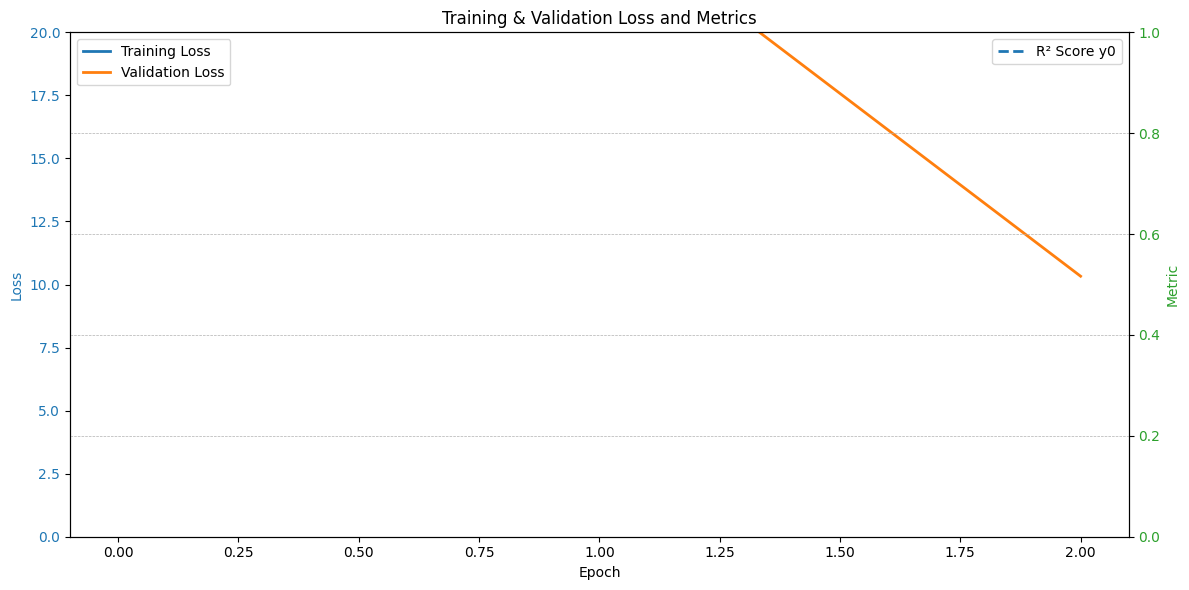

Training completed for TMA_net_run01. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(206, 1030, kernel_size=(5,), stride=(1,), padding=same, groups=206)
  (aggregate_block): Conv1d(1030, 1, kernel_size=(1,), stride=(1,), padding=same)
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((1030, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth


C:\Users\danie\AppData\Local\Temp\ipykernel_4196\1583759871.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Doe_run[i]['Y4'] = [np.array(tab) for tab in val_losses]
c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1024, 1])) that is different to the input size (torch.Size([1024, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarnin

Epoch 1/3 | Train Loss: 2007.0632 | Val Loss: 311.9760 | Val Mean Metrics: -51.5523
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 2/3 | Train Loss: 315.4979 | Val Loss: 306.5384 | Val Mean Metrics: -51.7820
Model saved at epoch 1 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 3/3 | Train Loss: 305.0786 | Val Loss: 306.8753 | Val Mean Metrics: -51.7820
Model saved at epoch 2 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth


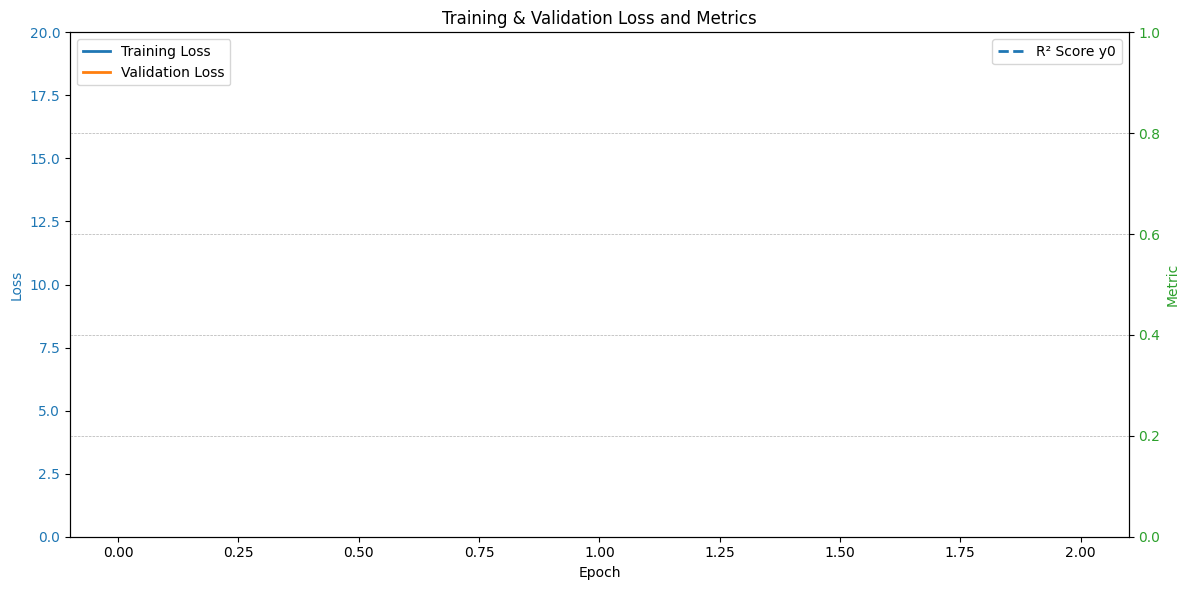

Training completed for TMA_net_run02. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.5, inplace=False)
  (conv1d): Conv1d(206, 1030, kernel_size=(1,), stride=(1,), padding=same, groups=206)
  (aggregate_block): Conv1d(1030, 1, kernel_size=(9,), stride=(1,), padding=same)
  (fc1): Linear(in_features=6, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (norm): LayerNorm((1030, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 504.7360 | Val Loss: 306.8781 | Val Mean Metrics: -51.7820
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preproce

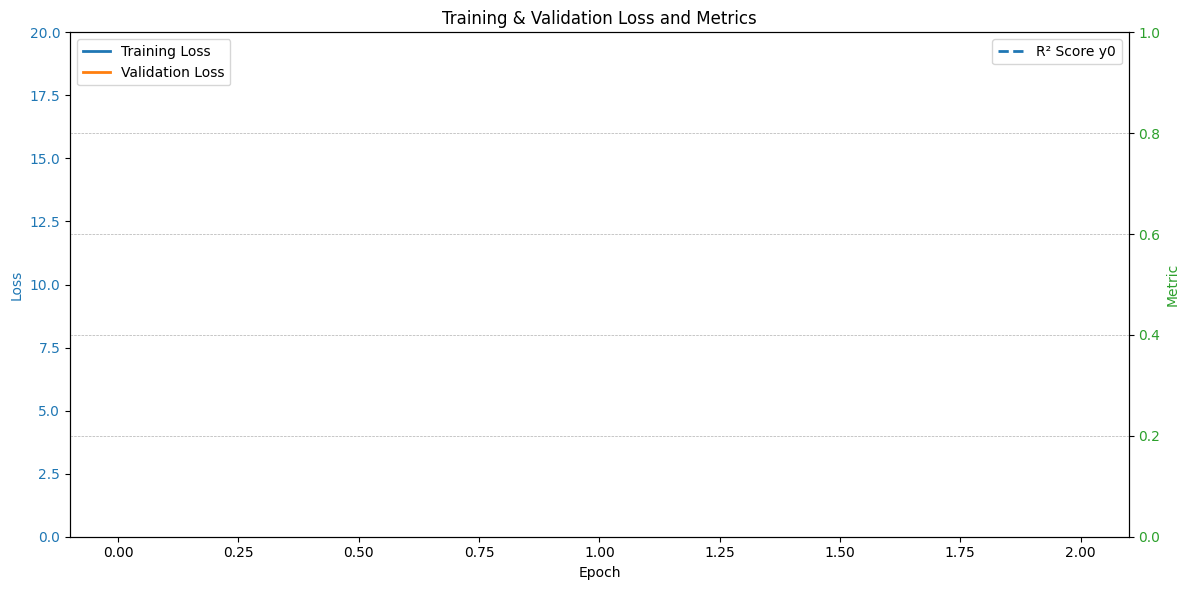

Training completed for TMA_net_run03. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.5, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(5,), stride=(1,), padding=same, groups=206)
  (aggregate_block): Conv1d(206, 1, kernel_size=(9,), stride=(1,), padding=same)
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 167.3623 | Val Loss: 71.4461 | Val Mean Metrics: -8.6315
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preproces

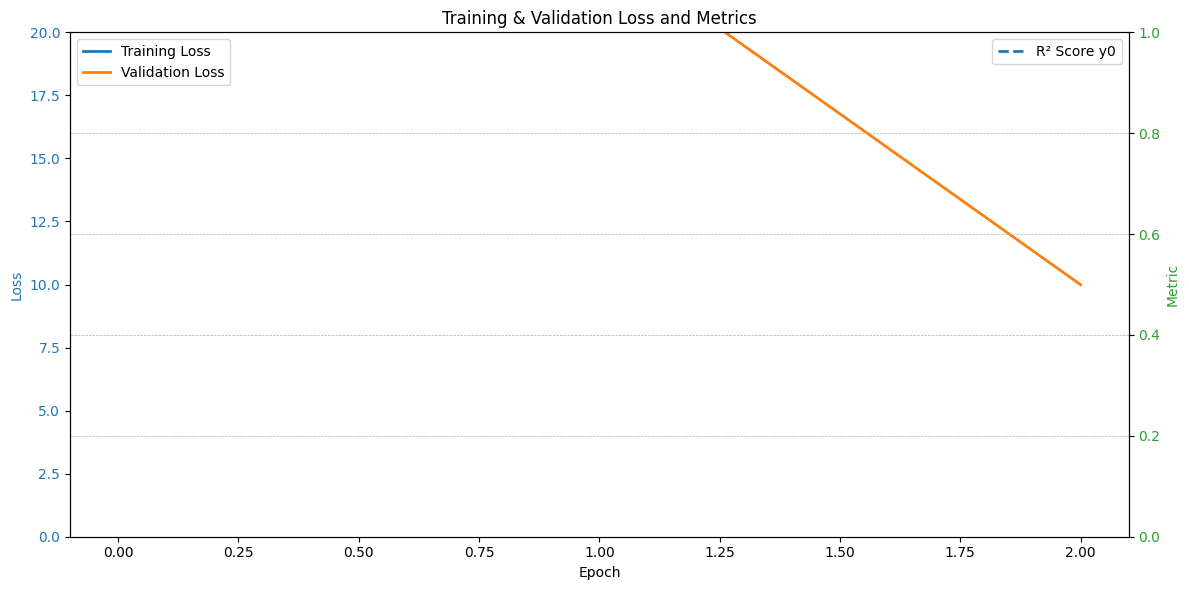

Training completed for TMA_net_run04. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(1,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 244.1999 | Val Loss: 149.9604 | Val Mean Metrics: -29.9841
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_M

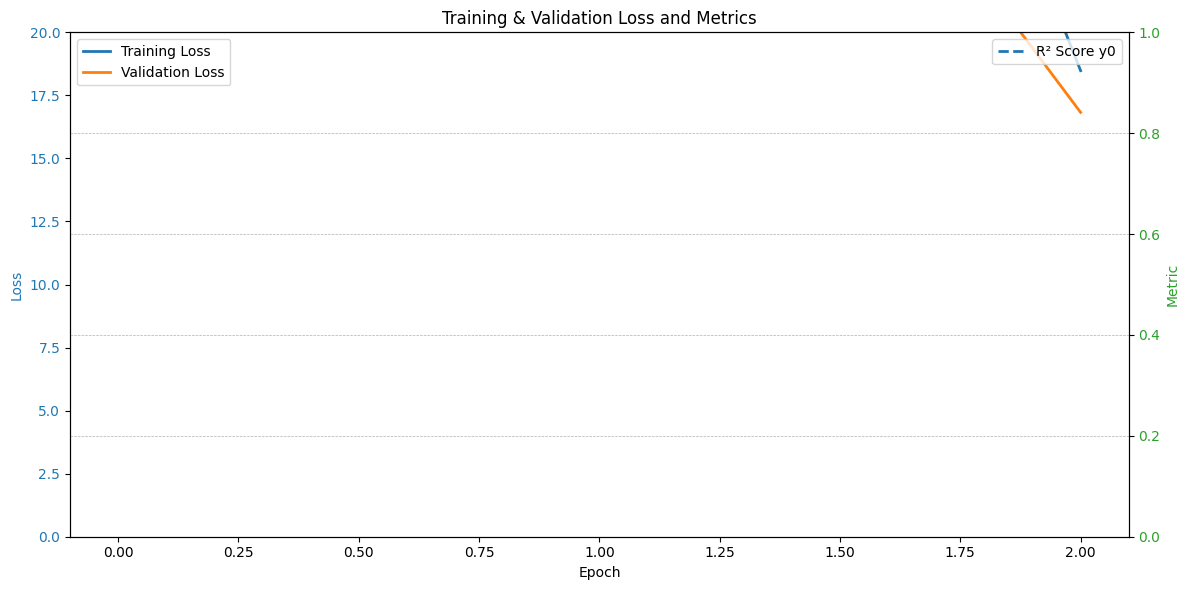

Training completed for TMA_net_run05. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.5, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(5,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=6, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 250.6852 | Val Loss: 214.1098 | Val Mean Metrics: -33.6592
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango

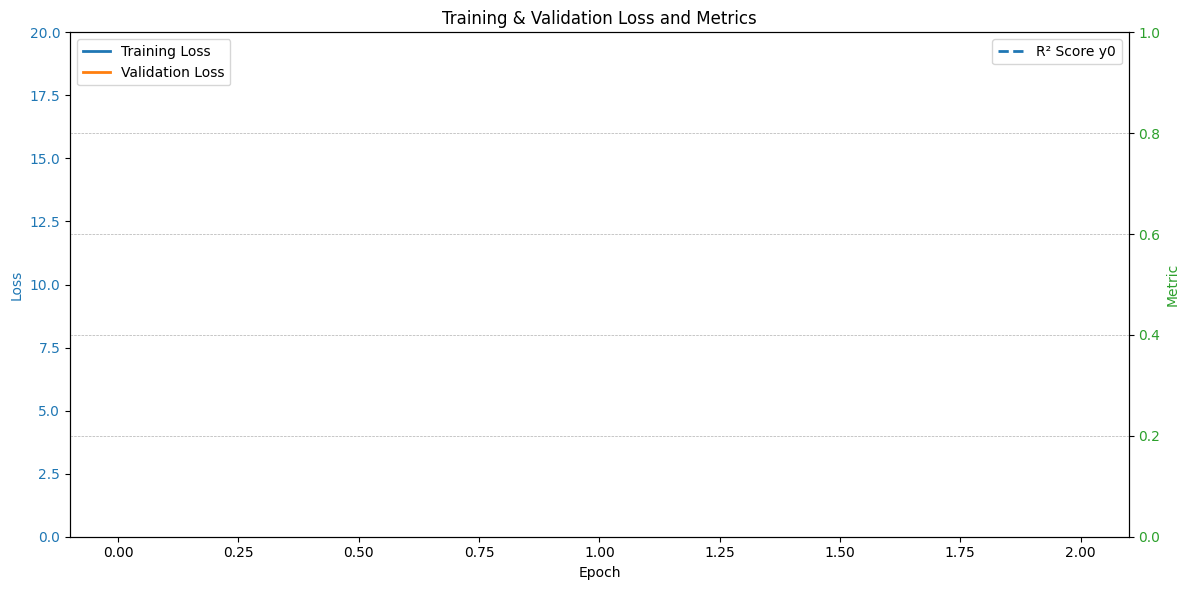

Training completed for TMA_net_run06. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.5, inplace=False)
  (conv1d): Conv1d(206, 1030, kernel_size=(5,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((1030, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 236.8837 | Val Loss: 152.6579 | Val Mean Metrics: -37.7149
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA

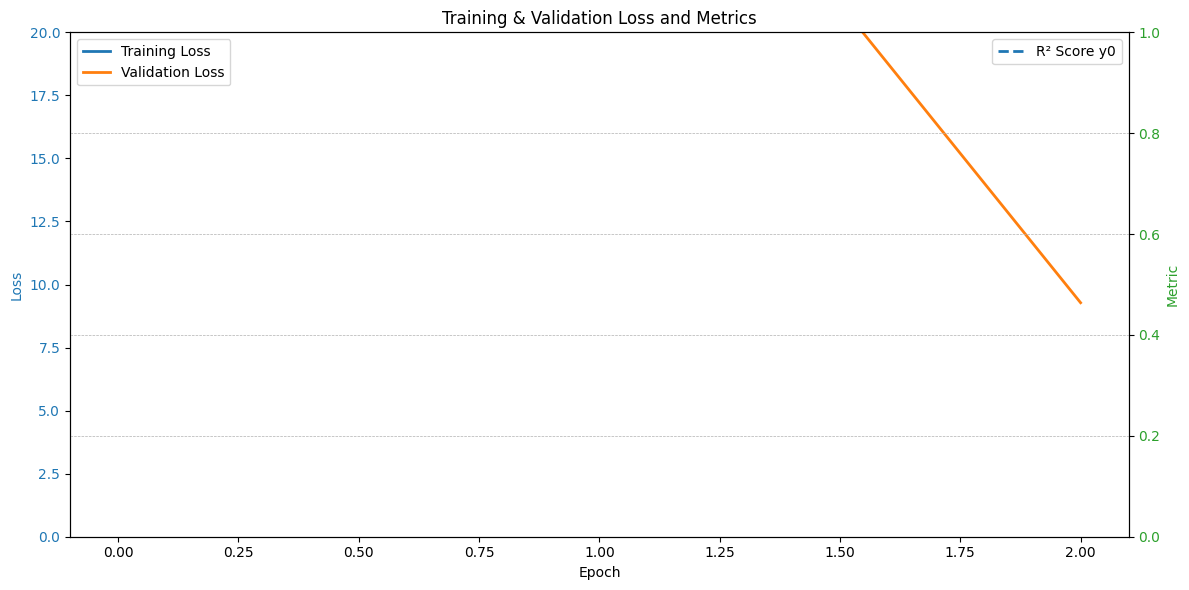

Training completed for TMA_net_run07. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(206, 1030, kernel_size=(1,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (norm): LayerNorm((1030, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 146.7008 | Val Loss: 67.7638 | Val Mean Metrics: -0.7839
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_

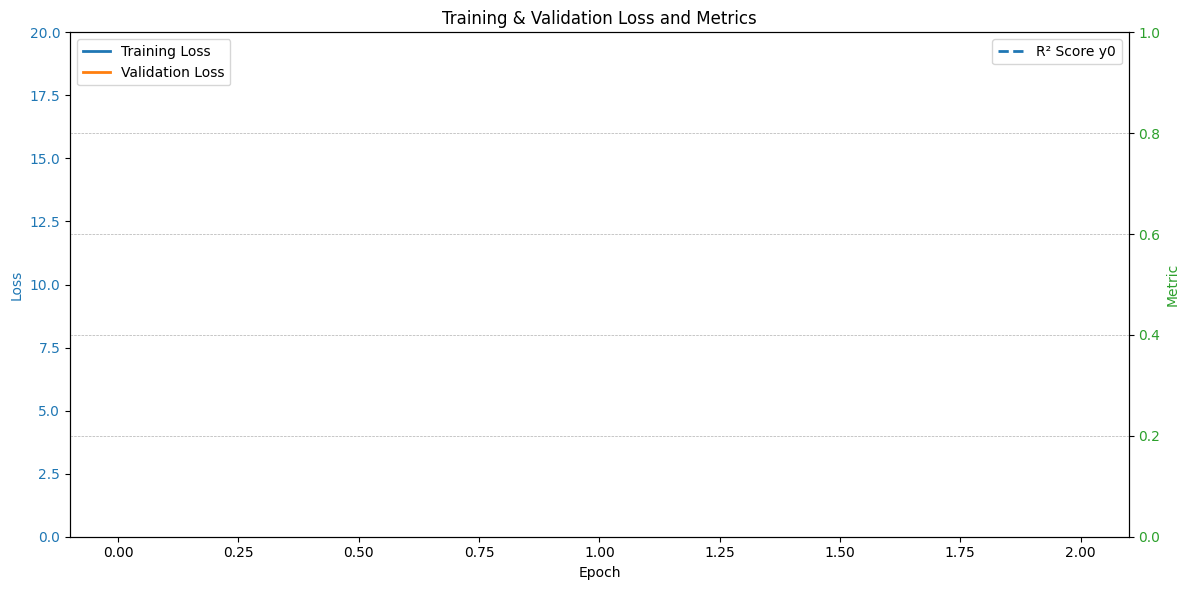

Training completed for TMA_net_run08. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(5,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=8, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 170.1499 | Val Loss: 93.3743 | Val Mean Metrics: -3.9825
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_be

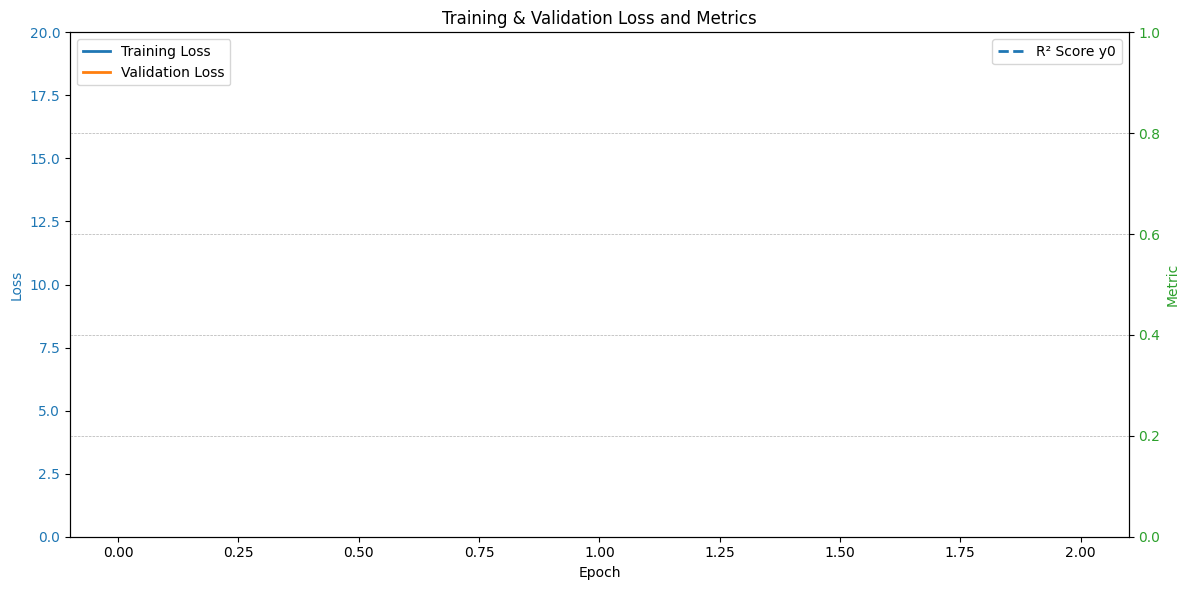

Training completed for TMA_net_run09. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(5,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 118.8371 | Val Loss: 57.6123 | Val Mean Metrics: -51.7812
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Man

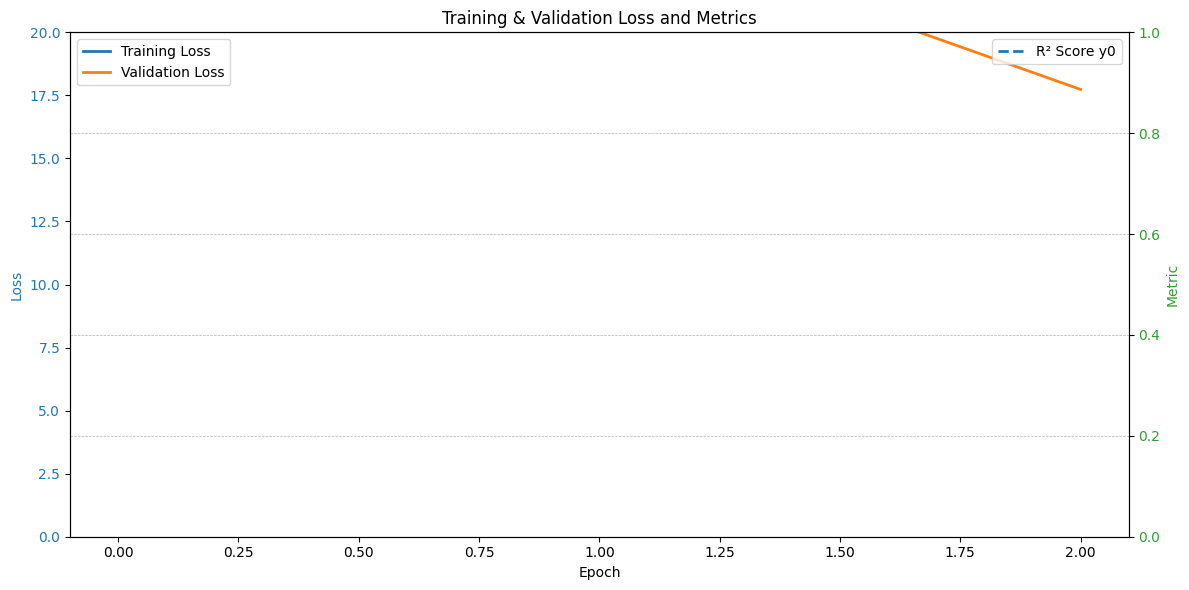

Training completed for TMA_net_run10. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.5, inplace=False)
  (conv1d): Conv1d(206, 206, kernel_size=(1,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((206, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 134.6394 | Val Loss: 65.2145 | Val Mean Metrics: -3.4959
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mang

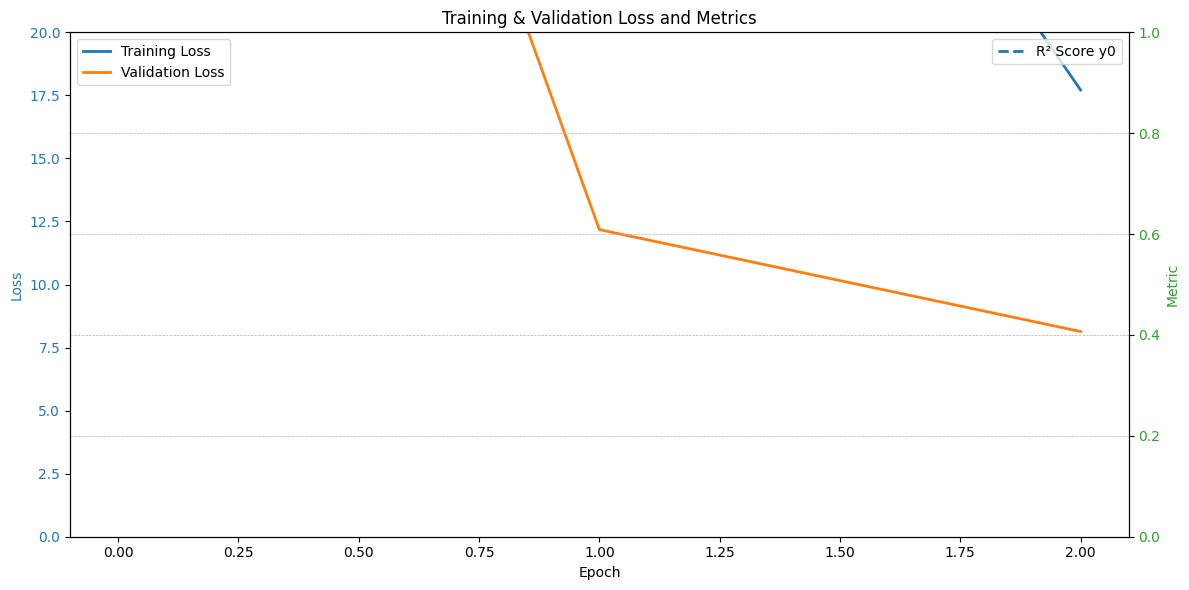

Training completed for TMA_net_run11. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.3, inplace=False)
  (conv1d): Conv1d(206, 618, kernel_size=(3,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=80, bias=True)
  (fc2): Linear(in_features=80, out_features=40, bias=True)
  (fc3): Linear(in_features=40, out_features=20, bias=True)
  (norm): LayerNorm((618, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=20, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth


c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1024, 1])) that is different to the input size (torch.Size([1024, 20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([550, 1])) that is different to the input size (torch.Size([550, 20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\danie\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-U7fd6DE6-py3.11\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a t

Epoch 1/3 | Train Loss: 147.6675 | Val Loss: 35.0995 | Val Mean Metrics: -6.6561
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 2/3 | Train Loss: 24.8957 | Val Loss: 10.7352 | Val Mean Metrics: -0.4514
Model saved at epoch 1 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 3/3 | Train Loss: 13.9058 | Val Loss: 7.1740 | Val Mean Metrics: 0.0913
Model saved at epoch 2 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Model saved at epoch 2 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth


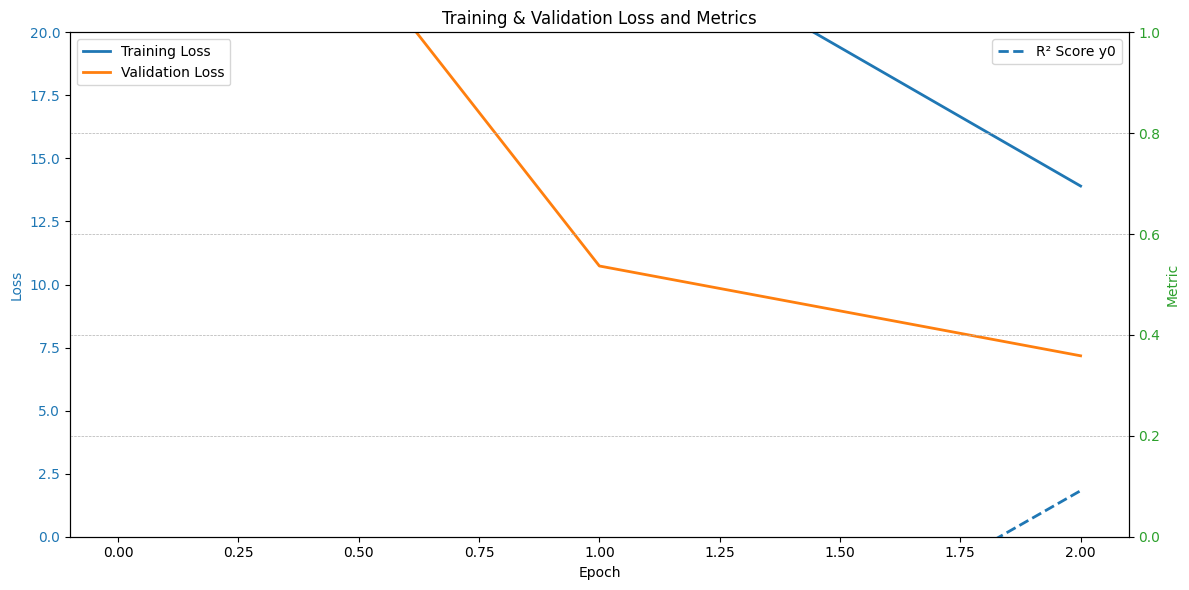

Training completed for TMA_net_run12. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.3, inplace=False)
  (conv1d): Conv1d(206, 618, kernel_size=(3,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=80, bias=True)
  (fc2): Linear(in_features=80, out_features=40, bias=True)
  (fc3): Linear(in_features=40, out_features=20, bias=True)
  (norm): LayerNorm((618, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=20, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 130.8849 | Val Loss: 46.3545 | Val Mean Metrics: -0.4319
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_

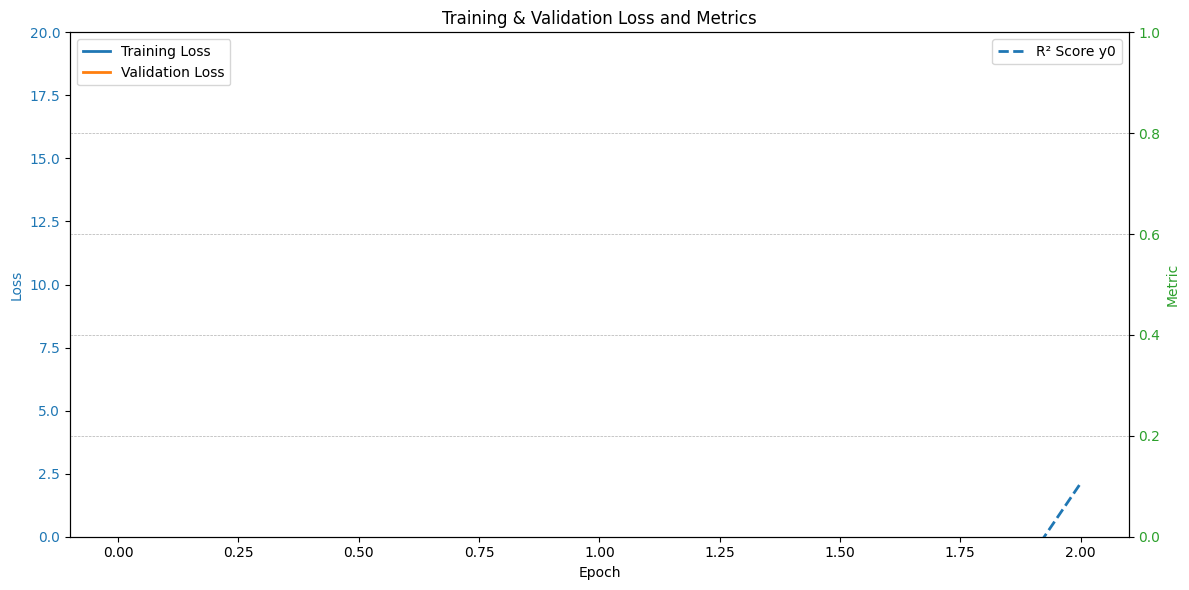

Training completed for TMA_net_run13. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]
TMA_net(
  (dropout): Dropout(p=0.3, inplace=False)
  (conv1d): Conv1d(206, 618, kernel_size=(3,), stride=(1,), padding=same, groups=206)
  (aggregate_block): channel_max()
  (fc1): Linear(in_features=6, out_features=80, bias=True)
  (fc2): Linear(in_features=80, out_features=40, bias=True)
  (fc3): Linear(in_features=40, out_features=20, bias=True)
  (norm): LayerNorm((618, 6), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=20, out_features=1, bias=True)
)
Saving best model to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
Epoch 1/3 | Train Loss: 122.4643 | Val Loss: 54.9192 | Val Mean Metrics: -1.1215
Model saved at epoch 0 to C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_

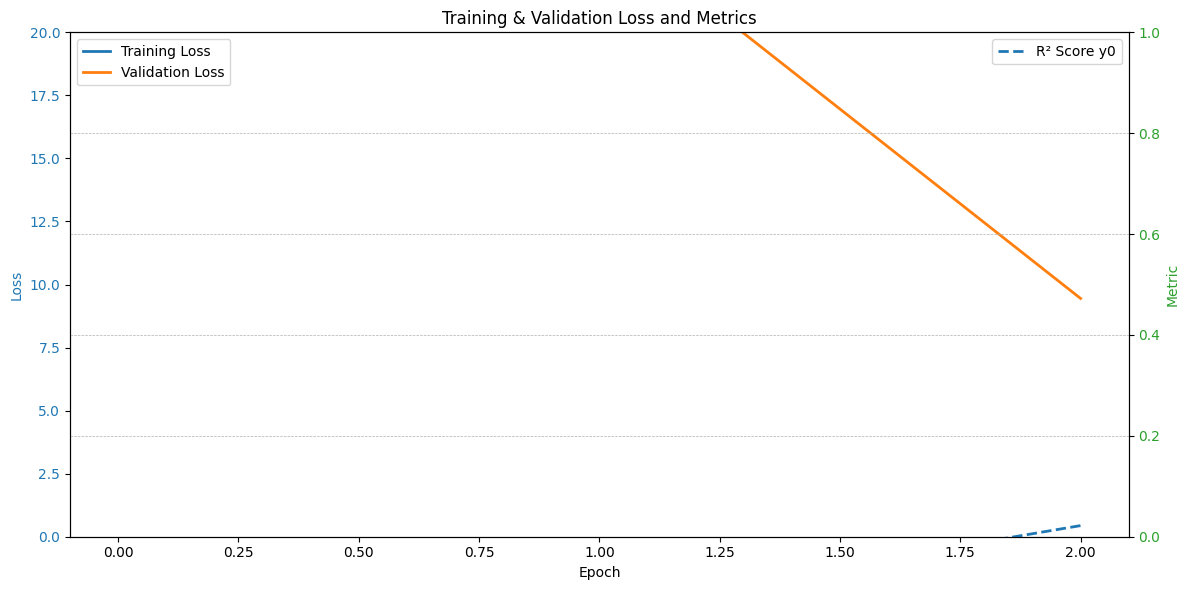

Training completed for TMA_net_run14. Final path: C:\Users\danie\Desktop\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\TMA_Mango_best.pth
[[ True]
 [ True]
 [ True]]


In [47]:
# define model parameters 
for i, exp in enumerate(Doe_run):
    model_name = 'TMA_net' + f"_run{exp['Exp No']:02d}"
    config.model_name = model_name
    model = TMA_net(input_dims = spec_dims, input_channel = x_cal_std.shape[1], kernel_size = exp['kernel_size'] ,aggregation_mode = exp['aggregation_mode'], n_filters = exp['n_filters'], kernel_size_aggregation = exp['kernel_size_aggregation'] ,fc1_dims = exp['fc_dim1'], dropout=exp['dropout'], out_dims=1)


    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
    criterion = nn.MSELoss(reduction='none')
    print(model)

    trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config)

    train_losses, val_losses,val_r2_scores, final_path = trainer.train()
    print(f"Training completed for {model_name}. Final path: {final_path}")
    Doe_run[i]['Y1'] = min(val_losses).numpy()  # Store the minimum validation loss
    bool = np.array(val_r2_scores) < 1.1
    print(bool)
    r = np.array(val_r2_scores)[bool]
    Doe_run[i]['Y2'] = max(r)  # Store the maximum R2 score 
    Doe_run[i]['Y3'] = val_r2_scores
    Doe_run[i]['Y4'] = [np.array(tab) for tab in val_losses]



In [46]:
print(Doe_run)

[{'Exp No': 1, 'Exp Name': 'N1', 'Run Order': 2, 'Incl/Excl': 'Incl', 'kernel_size': 1, 'aggregation_mode': 'conv', 'n_filters': 1, 'kernel_size_aggregation': 1, 'fc_dim1': 32, 'dropout': 0.1, 'Y1': array([73.19477], dtype=float32), 'Y2': np.float64(-38.393829345703125), 'Y3': [[-38.393829345703125], [-48.72975540161133], [-46.389190673828125]], 'Y4': [tensor([158.4328]), tensor([130.0395]), tensor([73.1948])]}, {'Exp No': 2, 'Exp Name': 'N2', 'Run Order': 11, 'Incl/Excl': 'Incl', 'kernel_size': 5, 'aggregation_mode': 'conv', 'n_filters': 5, 'kernel_size_aggregation': 1, 'fc_dim1': 128, 'dropout': 0.1, 'Y1': array([302.1894], dtype=float32), 'Y2': np.float64(-50.24906539916992), 'Y3': [[-50.24906539916992], [-51.29389572143555], [-51.78199768066406]], 'Y4': [tensor([302.1894]), tensor([306.5444]), tensor([306.2941])]}, {'Exp No': 3, 'Exp Name': 'N3', 'Run Order': 9, 'Incl/Excl': 'Incl', 'kernel_size': 1, 'aggregation_mode': 'conv', 'n_filters': 5, 'kernel_size_aggregation': 9, 'fc_dim1

CCC: 0.8368299308812179, R2: 0.7330573797225952, RMSEP: 1.3787686824798584
Shape of Y: (1448,), Shape of y_pred: (1448,)


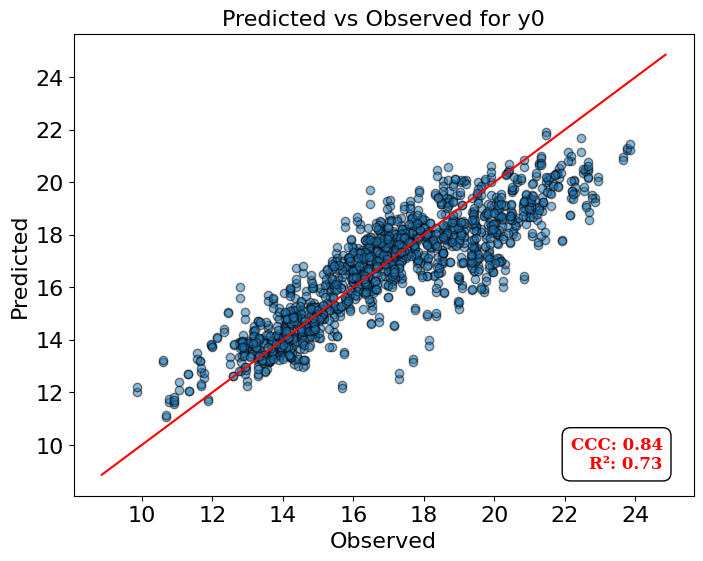

In [41]:

utils.test(model, final_path, test_loader,config)

In [14]:
model_name ="DeepSpectra_Mango"
config_deepsp = TrainerConfig(model_name = model_name)
config_deepsp.update_config(batch_size=1024,learning_rate=0.01,num_epochs=100,classification=False,max_loss_plot=20)

model = DeepSpectraCNN(spec_dims, mean = mean,std = std, out_dims=1) 
optimizer = optim.Adam(model.parameters(), lr=config_deepsp.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)
trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config_deepsp)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()


NameError: name 'DeepSpectraCNN' is not defined

CCC: 0.9217916719393322, R2: 0.8450840711593628, RMSEP: 1.0503414869308472


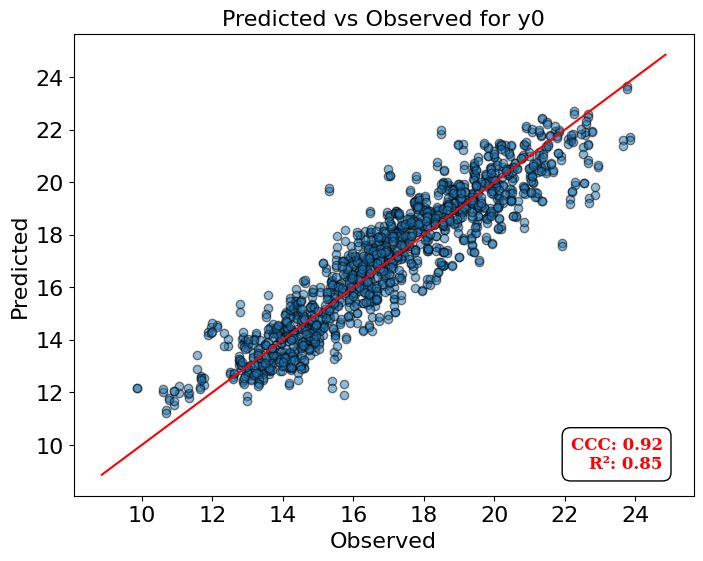

In [ ]:
utils.test(model, final_path, test_loader,config)

ResNet1D(
  (conv1): Sequential(
    (0): Conv1d(1, 8, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(8, 8, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(8, 8, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(8, 8, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(8, 8, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(8, eps=1e-05, 

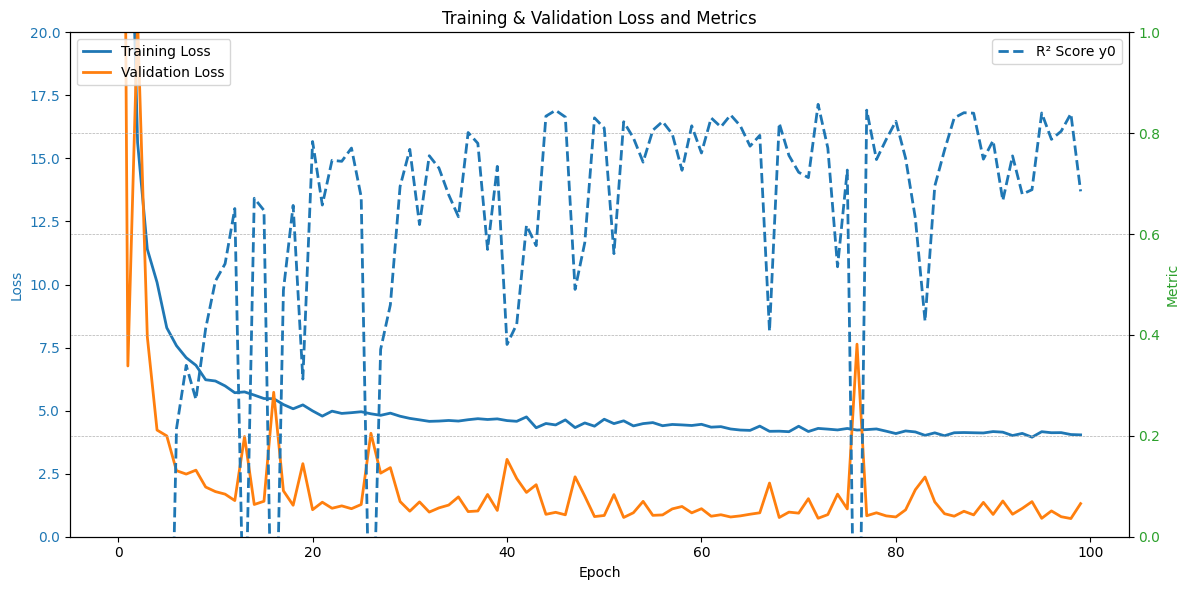

In [ ]:
# resnet 18 model test
model_name ="ResNET18_Mango"
config = TrainerConfig(model_name = model_name)
config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=100,classification=False,max_loss_plot=20)

model = ResNet18_1D(mean = mean,std = std, out_dims=1)
optimizer = optim.Adam(model.parameters(), lr=config_deepsp.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)
trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()



CCC: 0.8761566292354844, R2: 0.7791870832443237, RMSEP: 1.253991723060608


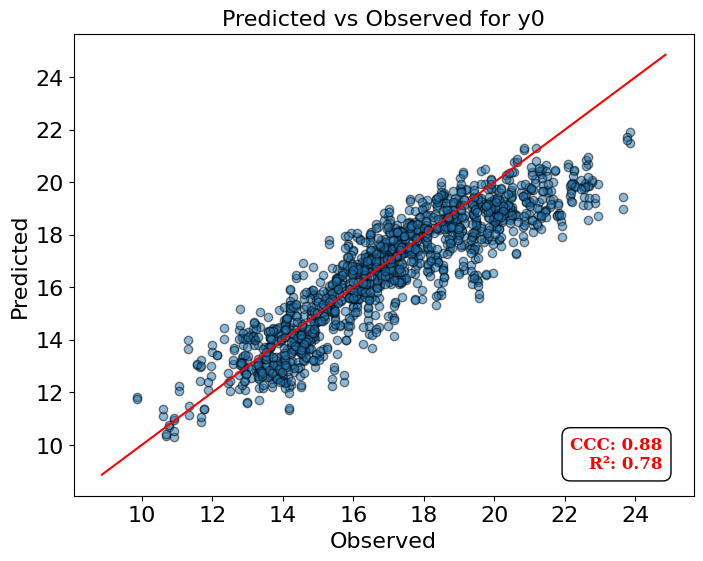

In [ ]:
utils.test(model, final_path, test_loader,config)

In [ ]:
model_name = "VIT1D"
config = TrainerConfig(model_name = model_name)
config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=20,classification=False,max_loss_plot=20)
print(config)

TrainerConfig(batch_size=1024, learning_rate=0.01, num_epochs=20, device=cuda, save_model=True,  classification=False, max_loss_plot=20,save_path=/home/metz/deepchemometrics/Aioly/models/VIT1D)


ViT_1D(
  (to_patch_embedding): Sequential(
    (0): Rearrange('b c (n p) -> b n (p c)', p=50)
    (1): LayerNorm((50,), eps=1e-05, elementwise_affine=True)
    (2): Linear(in_features=50, out_features=128, bias=True)
    (3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (transformer): Transformer(
    (layers): ModuleList(
      (0-19): 20 x ModuleList(
        (0): Attention(
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attend): Softmax(dim=-1)
          (dropout): Dropout(p=0.1, inplace=False)
          (to_qkv): Linear(in_features=128, out_features=1536, bias=False)
          (to_out): Sequential(
            (0): Linear(in_features=512, out_features=128, bias=True)
            (1): Dropout(p=0.1, inplace=False)
          )
        )
        (1): FeedForward(
          (net): Sequential(
            (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_fea

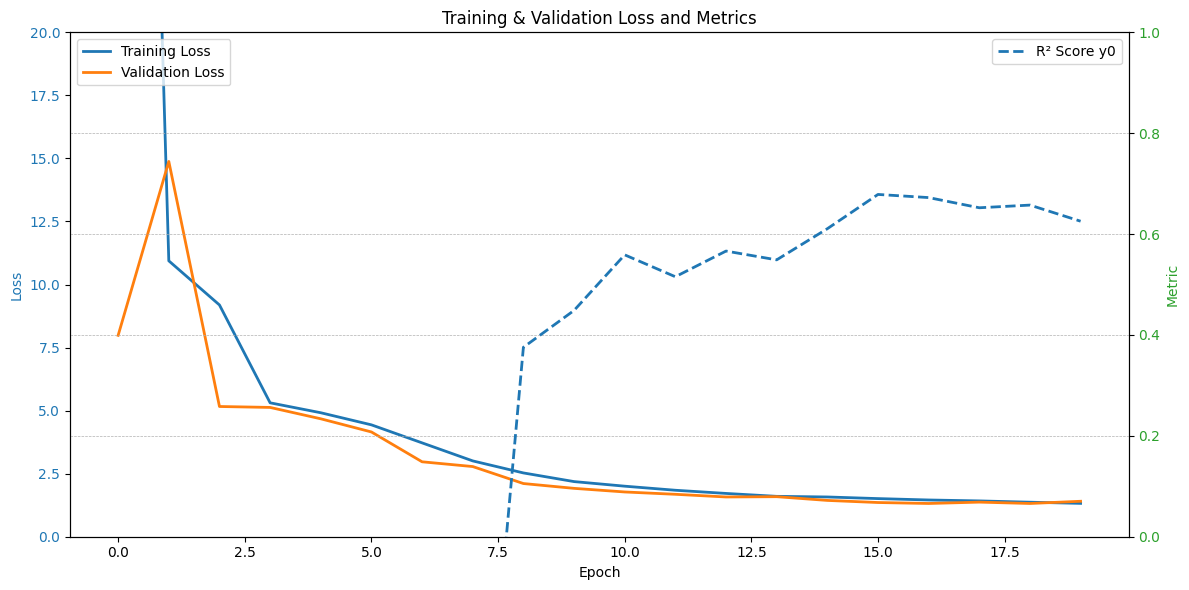

In [ ]:

model = ViT_1D(mean = mean,std = std, seq_len = spec_dims, patch_size = 50, dim_embed = 128, trans_layers = 20, heads = 8, mlp_dim = 512, out_dims =1, dropout=0.1)
optimizer = optim.Adam(model.parameters(), lr=config_deepsp.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)
trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()




CCC: 0.8246357125423807, R2: 0.7261631488800049, RMSEP: 1.396459698677063


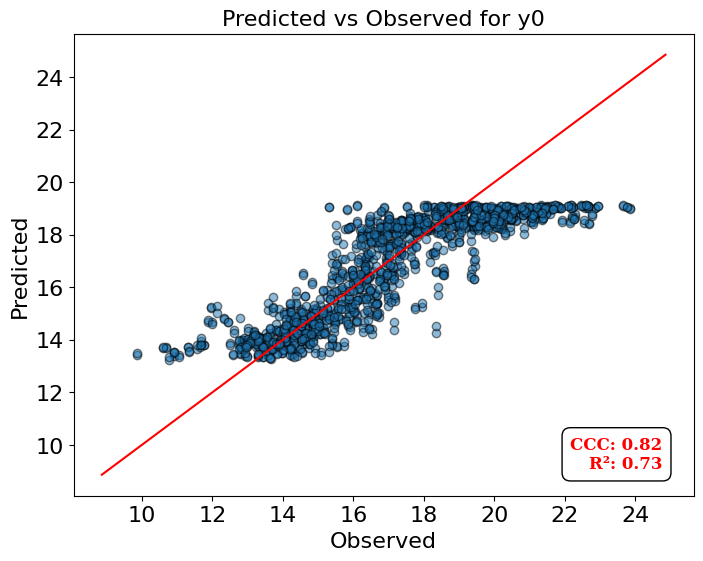

In [ ]:
utils.test(model, final_path, test_loader,config)